In [5]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
conn = sqlite3.connect(
    "../database/sustainability.db"
)

print("Database Connected")

Database Connected


In [7]:
query1 = """
SELECT
    c.country_name,
    ROUND(
        AVG(r.renewables_share_energy),
        2
    ) AS avg_renewable_energy

FROM Countries c

JOIN RenewableEnergy r
ON c.country_id = r.country_id

GROUP BY c.country_name

ORDER BY avg_renewable_energy DESC;
"""

result1 = pd.read_sql_query(
    query1,
    conn
)

result1

,country_name,avg_renewable_energy
0,Spain,14.44
1,Italy,12.40
2,Germany,11.04
3,France,8.97
4,China,8.90
5,India,6.92
6,United States,6.62


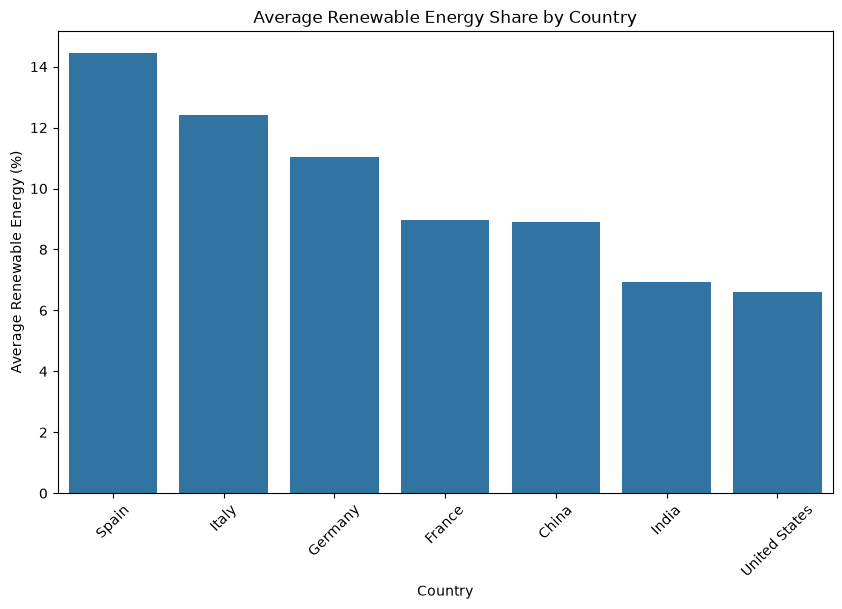

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=result1,
    x='country_name',
    y='avg_renewable_energy'
)

plt.title(
    'Average Renewable Energy Share by Country'
)

plt.xlabel('Country')

plt.ylabel(
    'Average Renewable Energy (%)'
)

plt.xticks(rotation=45)

plt.savefig(
    "../visuals/graph1_avg_renewable_energy.png",
     dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
query2 = """
SELECT
    c.country_name,
    ROUND(
        AVG(e.co2),
        2
    ) AS avg_co2

FROM Countries c

JOIN CO2Emissions e
ON c.country_id = e.country_id

GROUP BY c.country_name

ORDER BY avg_co2 DESC;
"""

result2 = pd.read_sql_query(
    query2,
    conn
)

result2

,country_name,avg_co2
0,China,8365.68
1,United States,5555.27
2,India,1872.22
3,Germany,801.60
4,Italy,409.80
5,France,358.82
6,Spain,288.54


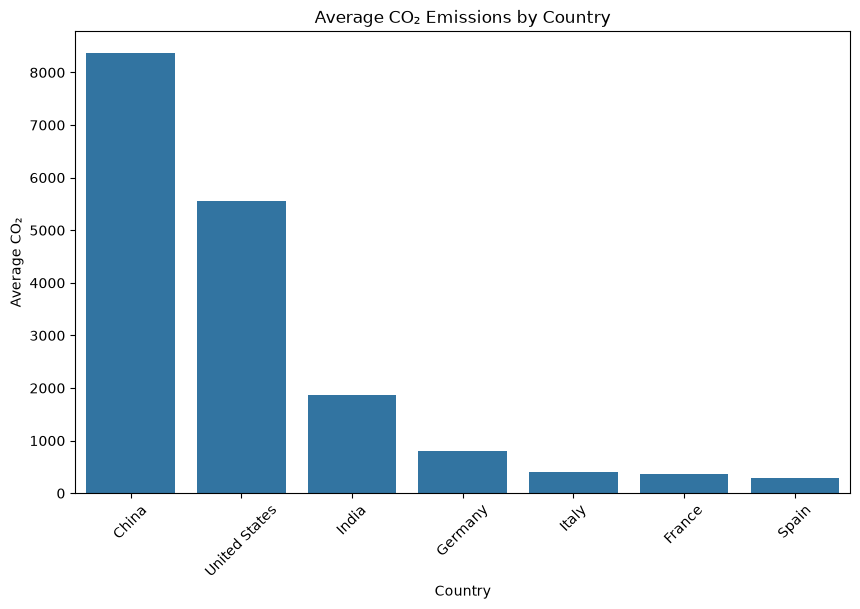

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=result2,
    x='country_name',
    y='avg_co2'
)

plt.title(
    'Average CO₂ Emissions by Country'
)

plt.xlabel('Country')

plt.ylabel('Average CO₂')

plt.xticks(rotation=45)

plt.savefig(
    "../visuals/graph2_avg_co2.png",
     dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
query3 = """
SELECT
    c.country_name,
    r.year,
    r.renewables_share_energy,
    e.co2

FROM Countries c

JOIN RenewableEnergy r
ON c.country_id = r.country_id

JOIN CO2Emissions e
ON c.country_id = e.country_id
AND r.year = e.year

ORDER BY
    c.country_name,
    r.year;
"""

trend_data = pd.read_sql_query(
    query3,
    conn
)

trend_data.head()

,country_name,year,renewables_share_energy,co2
0,China,2000,5.335688,3643.810
1,China,2001,6.251407,3724.114
2,China,2002,5.921867,4098.181
3,China,2003,5.001339,4835.251
4,China,2004,5.289435,5210.961


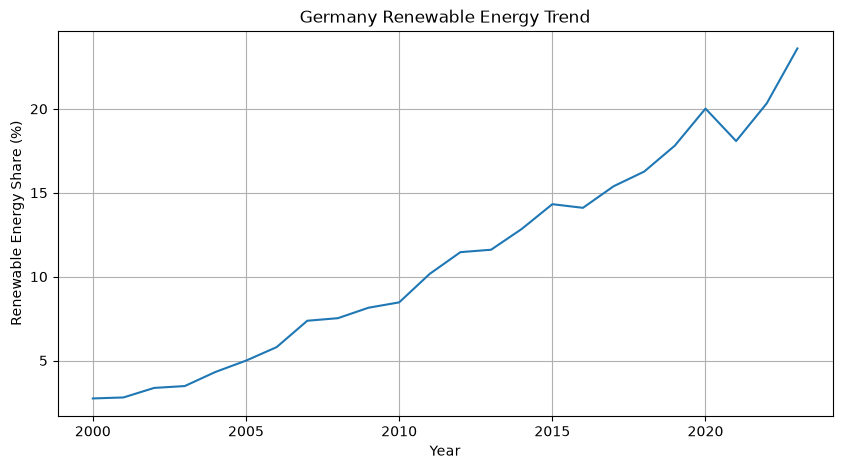

In [23]:
germany = trend_data[
    trend_data['country_name']
    == 'Germany'
]

plt.figure(figsize=(10,5))

plt.plot(
    germany['year'],
    germany['renewables_share_energy']
)

plt.title(
    'Germany Renewable Energy Trend'
)

plt.xlabel('Year')

plt.ylabel(
    'Renewable Energy Share (%)'
)

plt.grid(True)

plt.savefig(
    "../visuals/graph3_germany_renewable_trend.png",
     dpi=300,
    bbox_inches="tight"
)

plt.show()

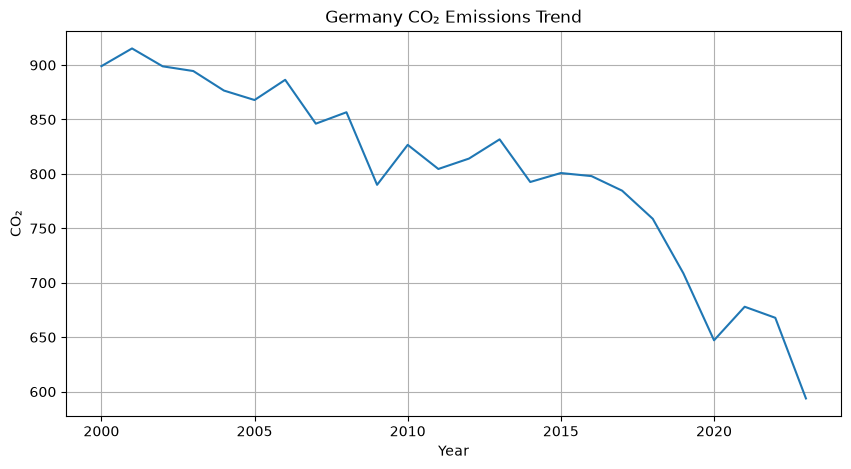

In [22]:
plt.figure(figsize=(10,5))

plt.plot(
    germany['year'],
    germany['co2']
)

plt.title(
    'Germany CO₂ Emissions Trend'
)

plt.xlabel('Year')

plt.ylabel('CO₂')

plt.grid(True)

plt.savefig(
    "../visuals/graph4_germany_co2_trend.png",
     dpi=300,
    bbox_inches="tight"
)

plt.show()

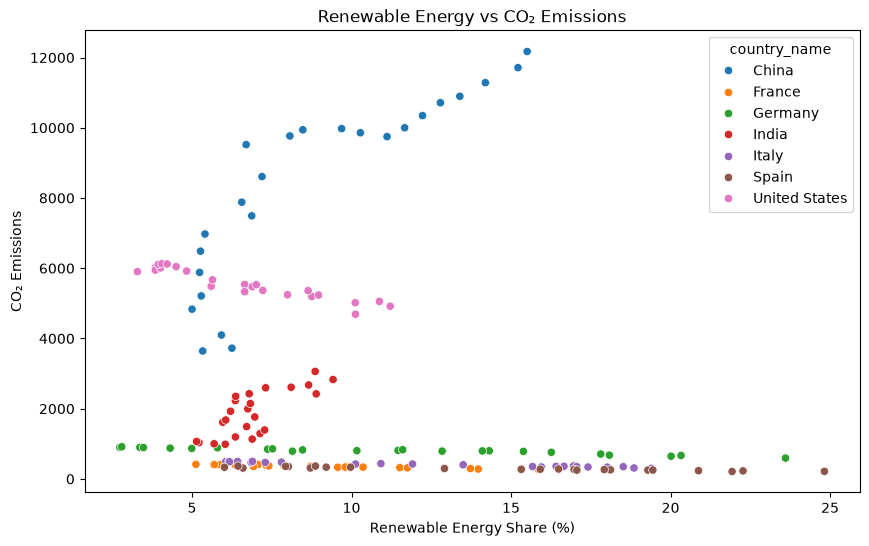

In [21]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=trend_data,
    x='renewables_share_energy',
    y='co2',
    hue='country_name'
)

plt.title(
    'Renewable Energy vs CO₂ Emissions'
)

plt.xlabel(
    'Renewable Energy Share (%)'
)

plt.ylabel('CO₂ Emissions')

plt.savefig(
    "../visuals/graph5_scatter_relationship.png",
     dpi=300,
    bbox_inches="tight"
)

plt.show()